### Preproccessing

#### Abstract

This notebook covers the full preprocessing pipeline for the ADS-B anomaly detection project. Starting from raw trajectory data for normal flights (~ 90 thousand flights) and accident flights (~160 flights), we will apply aircraft type filtering and stratified sampling to reduce normal flights to ~10 000, followed by outlier removal, resampling to a fixed grid. The result is a clean, leakage-free set of DataFrames ready for feature extraction and model training.

In [3]:

from paths import *
from glob import glob
import pandas as pd
import duckdb
import polars as pl


from src.common.plots import *
from src.common.data_integrity import *
from src.common.data_io import*

In [4]:
NORMAL_PATH = PROCESSED_DIR / "normal_traces_cleansed.parquet"
df_normal = pl.read_parquet(NORMAL_PATH)

In [5]:
df_normal["icao"].n_unique()

33593

In [6]:
df_normal["flight_id"].n_unique()

92410

In [7]:
df_normal.null_count() / len(df_normal) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_normal.columns

['icao',
 'type',
 'dbFlags',
 'timestamp',
 'lat',
 'lon',
 'altitude',
 'altitude_geom',
 'ground_speed',
 'track_degrees',
 'vertical_rate',
 'flags',
 'source',
 'h3_5',
 'flight_id']

We have ~34 thousand aircrafts (identified by ICAO) and ~92 thousand flights in the non-accident dataset

Let's import our accident trace- and meta- dataset 

In [9]:
df_acc_meta = import_df(PROCESSED_DIR, "asn_accident_metadata.csv")
df_acc = import_df(PROCESSED_DIR, "accidents_traces.csv")

In [10]:
len(df_acc["flight_id"].unique())

161

In [11]:
df_acc.isnull().sum() / len(df_acc) * 100

icao             0.0
type             0.0
dbFlags          0.0
timestamp        0.0
lat              0.0
lon              0.0
altitude         0.0
altitude_geom    0.0
ground_speed     0.0
track_degrees    0.0
vertical_rate    0.0
flags            0.0
source           0.0
h3_5             0.0
flight_id        0.0
t0               0.0
dtype: float64

In [12]:
df_acc_meta.columns

Index(['date', 'date_utc', 'time', 'time_utc', 'type', 'owner/operator',
       'icao', 'registration', 'msn', 'year of manufacture', 'engine model',
       'fatalities', 'other fatalities', 'aircraft damage', 'category',
       'location_country', 'location', 'phase', 'nature', 'departure airport',
       'destination airport', 'investigating agency', 'confidence rating',
       'narrative', 'record_id', 'record_url', 'total airframe hrs', 'cycles',
       'timestamp'],
      dtype='str')

In [13]:
df_acc_meta.head(5)

,date,date_utc,time,time_utc,type,owner/operator,icao,registration,msn,year of manufacture,...,departure airport,destination airport,investigating agency,confidence rating,narrative,record_id,record_url,total airframe hrs,cycles,timestamp
0,Tuesday 21 March 2023,2023-03-21,15:23 LT,22:23,Boeing 777-224ER,United Airlines,aaba9a,N79011,29859/227,1999.0,...,"San Francisco International Airport, CA (SFO/K...",MÃ¼nchen-Franz Josef Strauss Airport (MUC/EDDM),NTSB,Accident investigation report completed and in...,United Airlines flight UA194 encountered conve...,309736,https://aviation-safety.net/wikibase/309736,101792 hours,NaN,2023-03-21 22:23:00+00:00
1,Wednesday 22 March 2023,2023-03-22,17:26 LT,22:26,Airbus A320-232,United Airlines,a16adc,N1902U,2714,2006.0,...,Mexico City-Benito JuÃ¡rez International Airpo...,"Houston-George Bush Intercontinental Airport, ...",NTSB,Accident investigation report completed and in...,United Airlines flight UA1091 sustained a tail...,311365,https://aviation-safety.net/wikibase/311365,22194 hours,NaN,2023-03-22 22:26:00+00:00
2,Friday 24 March 2023,2023-03-24,10:15,16:15,McDonnell Douglas MD-88 (SF),USA Jet Airlines,ab6909,N834US,53259/1849,1991.0,...,"Detroit-Willow Run Airport, MI (YIP/KYIP)",Saltillo-Plan de Guadalupe International Airpo...,NTSB,Accident investigation report completed and in...,"USA Jet Airlines, flight JUS834, sustained a t...",311093,https://aviation-safety.net/wikibase/311093,NaN,NaN,2023-03-24 16:15:00+00:00
3,Sunday 9 April 2023,2023-04-09,17:29,16:29,Boeing 737-8AS (WL),Ryanair,4ca264,EI-DHH,33817/1677,2005.0,...,Liverpool-John Lennon International Airport (L...,Dublin Airport (DUB/EIDW),AAIU,Accident investigation report completed and in...,"Ryanair flight FR5542, a Boeing 737-8AS, suffe...",310217,https://aviation-safety.net/wikibase/310217,NaN,NaN,2023-04-09 16:29:00+00:00
4,Thursday 13 April 2023,2023-04-14,c. 21,01:00,Airbus A330-243,Air Transat,c0799e,C-GUBL,728,2006.0,...,"Toronto-Pearson International Airport, ON (YYZ...","Miami International Airport, FL (MIA/KMIA)",NTSB,"Information is only available from news, socia...","Air Transat flight TS948, an Airbus A330-243 (...",318686,https://aviation-safety.net/wikibase/318686,NaN,NaN,2023-04-14 01:00:00+00:00


In [14]:
print("=== Aircraft types ===")
print(df_acc_meta["type"].value_counts().head(12))

=== Aircraft types ===
type
Boeing 787-9 Dreamliner         10
Bombardier CRJ-900LR             6
Boeing 737-7H4 (WL)              5
Boeing 737 MAX 8                 5
Boeing 737-8AS (WL)              4
Boeing 737-924ER (WL)            4
Airbus A320-214                  4
Airbus A350-941                  4
Boeing 737 MAX 9                 4
Bombardier DHC-8-402Q Dash 8     4
Embraer ERJ-175LR                3
Boeing 767-322ER (WL)            3
Name: count, dtype: int64


Almost exclusively commercial jets. Boeing dominates clearly, led by the 787-9 (10 aircraft) 
and various 737 variants. Airbus is represented with 8 aircraft (A320, A350), and regional 
aircraft appear only marginally (Embraer ERJ-175, Bombardier DHC-8 as the sole turboprop).

In [15]:
print("=== Engine model ===")
print(df_acc_meta["engine model"].value_counts().head(15))

=== Engine model ===
engine model
CFMI CFM56-7B               26
CFMI CFM LEAP-1B            10
GE CF34-8C5                  7
P&W Canada PW127             6
General Electric CF34-8E     5
CFMI CFM56-5B4/P             5
Rolls-Royce Trent XWB-84     4
GE GEnx-1B                   4
P&W Canada PW150             4
IAE V2527-A5                 3
CFMI CFM56-7B24              3
P&W 1500G                    3
P&W JT8D-200                 2
CFMI CFM56-7B26E             2
CFMI CFM LEAP-1A33           2
Name: count, dtype: int64


The engine models reflect a fairly typical commercial fleet composition. The majority are narrow-body workhorses (CFM56/LEAP on 737s), which makes sense as these cover the bulk of short to medium-haul routes. A smaller portion of wide-body engines (GEnx, Trent XWB) suggests some long-haul capability in the dataset. Regional jet engines (CF34) cover thinner routes where smaller aircraft are more economical, and the turboprop engines (PW127/150) point to short-hop or regional feeder operations where jets wouldn't be cost-effective.

In [16]:
print("\n=== Operators ===")
print(df_acc_meta["owner/operator"].value_counts().head(13))


=== Operators ===
owner/operator
United Airlines                       19
Delta Air Lines                       15
Southwest Airlines                    11
American Airlines                      6
Delta Connection, opb Endeavor Air     5
Japan Airlines (JAL)                   5
Ryanair                                4
Alaska Airlines                        4
Air France                             3
Condor Flugdienst                      3
Malta Air, opf Ryanair                 3
All Nippon Airways - ANA               3
Air Transat                            2
Name: count, dtype: int64


Dominated by major U.S. airlines (United, Delta, Southwest)

In [17]:
print("\n=== Year of manufacture ===")
print(df_acc_meta["year of manufacture"].describe())


=== Year of manufacture ===
count     143.000000
mean     2009.027972
std         9.400288
min      1954.000000
25%      2003.000000
50%      2010.000000
75%      2016.500000
max      2023.000000
Name: year of manufacture, dtype: float64


The fleet spans from 1990 to 2023, with a median manufacture year of 2010, so a relatively modern but mixed-age fleet.

In [18]:
print("\n=== Location country ===")
print(df_acc_meta["location_country"].value_counts().head(10))


=== Location country ===
location_country
United States of America    75
Canada                      11
United Kingdom              10
Japan                        8
Spain                        7
Brazil                       3
France                       3
Türkiye                      3
Germany                      3
Ireland                      2
Name: count, dtype: int64


Aircraft are predominantly registered in the US (73), followed by Canada and the UK, suggesting a strong North American focus in the dataset, with some European and Asian representation.

In [19]:
print("\n=== Phase of accident ===")
print(df_acc_meta["phase"].value_counts())



=== Phase of accident ===
phase
En route             57
Landing              43
Taxi                 22
Standing             12
Approach              8
Pushback / towing     6
Take off              4
Initial climb         3
Unknown               1
Name: count, dtype: int64


That’s the most interesting finding. En route (57) and Landing (42) dominate, not Descent/Approach as one might expect. This means the entire flight is the better choice for our model.

In [20]:
print("\n=== Nature of flight ===")
print(df_acc_meta["nature"].value_counts())


=== Nature of flight ===
nature
Passenger - Scheduled                         134
Cargo                                          11
Passenger - Non-Scheduled/charter/Air Taxi      4
Ferry/positioning                               4
Private                                         1
Passenger                                       1
-                                               1
Name: count, dtype: int64


134 are scheduled passenger flights. This is a very homogeneous group.

In [21]:
print("\n=== Aircraft damage ===")
print(df_acc_meta["aircraft damage"].value_counts())

print("\n=== Category ===")
print(df_acc_meta["category"].value_counts())


=== Aircraft damage ===
aircraft damage
Substantial                 39
Substantial, repaired       33
Minor                       13
Unknown                      4
Destroyed, written off       3
Destroyed                    3
Substantial, written off     2
Minor, repaired              1
Name: count, dtype: int64

=== Category ===
category
Accident            150
Serious incident      3
Other                 2
Name: count, dtype: int64


Mostly substantial but not destroyed. So these are more serious incidents than total crashes.

#### Consequences for Sampling Strategy

Our accidents are very homogeneous, commercial jets, predominantly US-based and European major airlines (United, Delta, Ryanair, Air France). Random sampling from ~92 normal flights carries the risk of including too many "exotic" flights that aren't comparable to our accidents at all.

We prefer stratified sampling focusing on large jets. This covers our accident population well without being too restrictive.

We will now shrink our non-accident (normal) dataset as ~92 thousand flights are too much and not-needed, as we assume.

In [22]:
from src.preproccessing.resampling import * 

#### Aircraft type filtering

In [23]:
accident_types = df_acc["type"].unique().tolist()

df_normal = df_normal.filter(
    pl.col("type").is_in(accident_types)
)

print(f"Flights after type filter: {df_normal['flight_id'].n_unique()}")

Flights after type filter: 55240


In [24]:
df_acc["type"].unique()

<ArrowStringArray>
['B190', 'A343', 'B789', 'B738', 'SU95', 'B77W', 'A320', 'A359', 'A306',
 'B753', 'E145', 'A388', 'A21N', 'AT76', 'E195', 'AT75', 'E190', 'BCS3',
 'B38M', 'B744', 'A333', 'A20N', 'A321', 'DH8C', 'B788', 'B763', 'AT45',
 'E75L', 'B752', 'B737', 'B39M', 'B739', 'CRJ9', 'A319', 'A339', 'CRJ2',
 'CRJ7', 'B772', 'B764', 'E170', 'MD83', 'MD88', 'B712', 'DH8D', 'B734',
 'M20P', 'A332']
Length: 47, dtype: str

In [25]:
df_normal["type"].unique()

type
str
"""B39M"""
"""AT75"""
"""B772"""
"""DH8D"""
"""B77W"""
…
"""B753"""
"""B763"""
"""B712"""


We cluster aircraft type and see the distribution. We will aim a similar distribution in out normal trace dataset.

In [26]:
family_map = {
    # Boeing 737
    "B737": "B737_family", "B738": "B737_family", "B739": "B737_family",
    "B734": "B737_family", "B38M": "B737_family", "B39M": "B737_family",
    # Boeing 757
    "B752": "B757_family", "B753": "B757_family",
    # Boeing 767
    "B763": "B767_family",
    # Boeing 777
    "B772": "B777_family", "B77W": "B777_family", "B77L": "B777_family",
    # Boeing 787
    "B788": "B787_family", "B789": "B787_family",
    # Boeing 747
    "B744": "B747_family",
    # Boeing 717
    "B712": "B717_family",
    # Airbus A320 family
    "A319": "A320_family", "A320": "A320_family", "A321": "A320_family",
    "A20N": "A320_family", "A21N": "A320_family",
    # Airbus A330
    "A332": "A330_family", "A333": "A330_family", "A339": "A330_family",
    # Airbus A350
    "A359": "A350_family",
    # Airbus A300
    "A306": "A300_family",
    # Airbus A220
    "BCS3": "A220_family",
    # Embraer
    "E75L": "Embraer", "E170": "Embraer", "E190": "Embraer",
    "E195": "Embraer", "E145": "Embraer",
    # Bombardier
    "CRJ9": "Bombardier", "CRJ2": "Bombardier", "CRJ7": "Bombardier",
    "DH8D": "Bombardier",
    # ATR
    "AT76": "ATR", "AT75": "ATR",
    # Other
    "MD88": "Other", "MD83": "Other", "SU95": "Other", "M20P": "Other",
}

In [27]:
unmapped = [t for t in df_acc["type"].unique().tolist() if t not in family_map]
print(f"Unmapped: {unmapped}")

Unmapped: ['B190', 'A343', 'A388', 'DH8C', 'AT45', 'B764']


In [28]:
acc_distribution = (
    df_acc["type"]
    .map(family_map)
    .value_counts(normalize=True)
    .sort_index()
)

In [29]:
acc_distribution

type
A220_family    0.031949
A300_family    0.037629
A320_family    0.131798
A330_family    0.028007
A350_family    0.018753
ATR            0.026526
B717_family    0.004982
B737_family    0.363189
B747_family    0.028889
B757_family    0.045855
B767_family    0.072662
B777_family    0.027934
B787_family    0.024249
Bombardier     0.061144
Embraer        0.075257
Other          0.021177
Name: proportion, dtype: float64

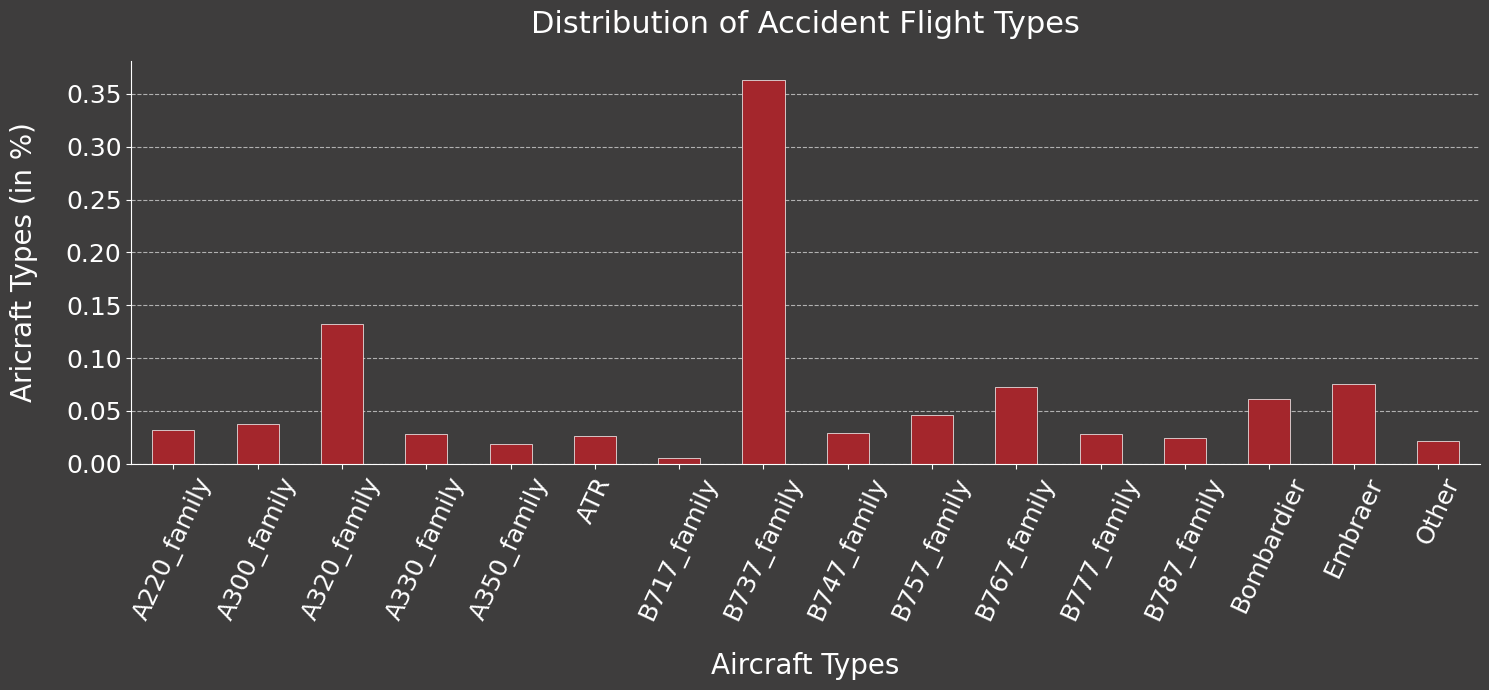

In [30]:
save_path = IMAGE_DIR / "type_distro_acc.png"
plot_bar(acc_distribution, "Distribution of Accident Flight Types", ylabel="Aricraft Types (in %)",
          xlabel="Aircraft Types", rotate_xticks = 65, transparent = True, save_path = save_path, dark_mode = True)

In [31]:
flights_unique = (
    df_normal
    .select(["flight_id", "type"])
    .unique(subset=["flight_id"] , maintain_order=True)
    .with_columns(
        pl.col("type").replace(family_map).alias("family")
    )
)

In [32]:
normal_distribution = (
    df_normal["type"].to_pandas()
    .map(family_map)
    .value_counts(normalize=True)
    .sort_index()
)

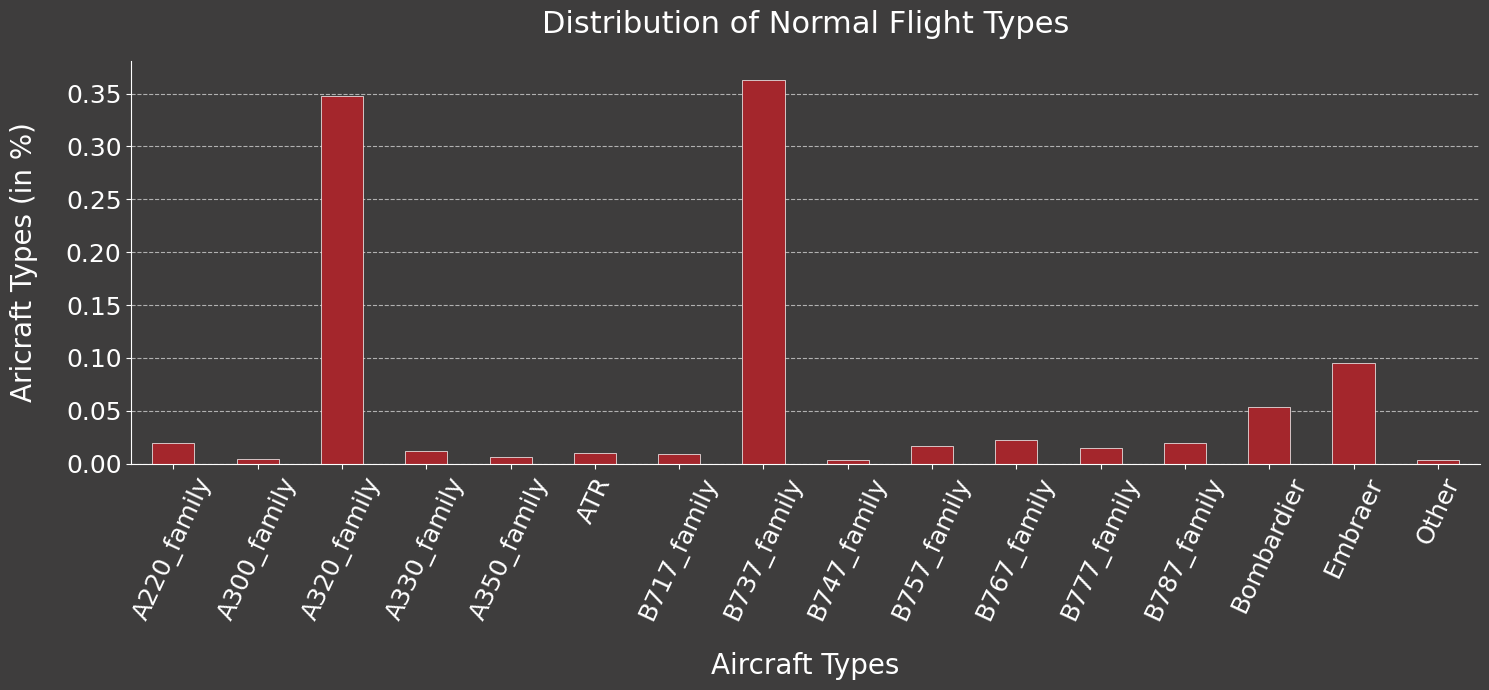

In [33]:
save_path = IMAGE_DIR / "type_distro_normal.png"
plot_bar(normal_distribution, "Distribution of Normal Flight Types", ylabel="Aricraft Types (in %)",
          xlabel="Aircraft Types", rotate_xticks = 65, transparent = True, save_path = save_path, dark_mode = True)

In [164]:
# Stratified sample based on accident distribution
target_n = 2000
sampled_ids = []

for family, ratio in acc_distribution.items():
    n = round(target_n * ratio)
    pool = flights_unique.filter(pl.col("family") == family)
    if len(pool) >= n:
        sampled_ids.append(pool.sample(n=n, seed=42))
    else:
        sampled_ids.append(pool)  

In [165]:
sampled = pl.concat(sampled_ids)
print(f"Sampled flights: {len(sampled)}")
print(sampled["family"].value_counts())

Sampled flights: 2000
shape: (16, 2)
┌─────────────┬───────┐
│ family      ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ B717_family ┆ 10    │
│ B747_family ┆ 58    │
│ Embraer     ┆ 151   │
│ A320_family ┆ 264   │
│ Other       ┆ 42    │
│ …           ┆ …     │
│ B767_family ┆ 145   │
│ Bombardier  ┆ 122   │
│ A220_family ┆ 64    │
│ A300_family ┆ 75    │
│ B777_family ┆ 56    │
└─────────────┴───────┘


In [166]:
sampled_distribution = (
    sampled["family"]
    .value_counts(normalize=True)
)

In [168]:
sampled_distribution = sampled_distribution.to_pandas().set_index("family")["proportion"]
sampled_distribution = sampled_distribution.sort_index()

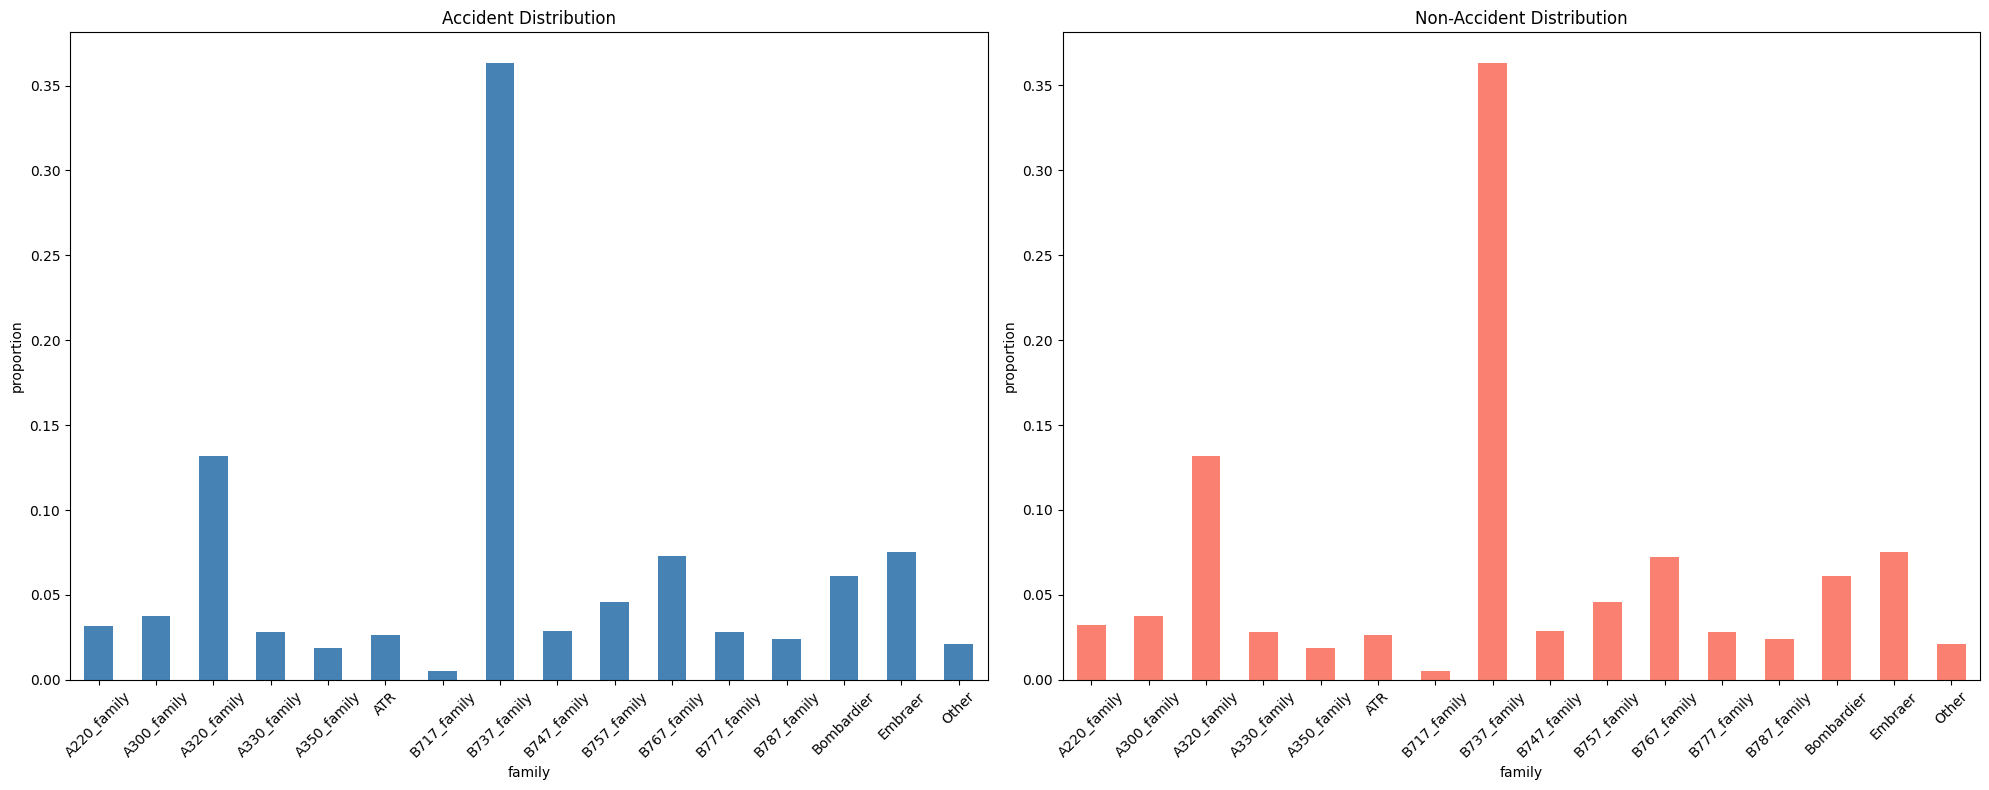

In [169]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

acc_distribution.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Accident Distribution")
axes[0].set_xlabel("family")
axes[0].set_ylabel("proportion")
axes[0].tick_params(axis="x", rotation=45)

sampled_distribution.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Non-Accident Distribution")
axes[1].set_xlabel("family")
axes[1].set_ylabel("proportion")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The sampled normal flights closely mirror the accident type distribution across all families, confirming the stratified sampling worked as intended.

In [170]:
sampled_ids = sampled["flight_id"].to_list()

In [171]:
len(sampled_ids)


2000

In [172]:
df_normal_final = (
    pl.scan_parquet(NORMAL_PATH)
    .filter(pl.col("flight_id").is_in(sampled_ids))
    .collect()
)

print(f"Final traces: {len(df_normal_final)}")
print(f"Final Flights: {len(df_normal_final["flight_id"].unique())}")

Final traces: 1101148
Final Flights: 2000


#### Distribution Trace-Duration

In [174]:
df_acc

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id,t0
0,00a61a,B190,0,2023-11-01 07:39:08.950000+00:00,-26.593781,27.656371,21950.0,23375.0,209.4,208.703482,64.0,4,adsb_icao,85bcc38ffffffff,00a61a,2023-11-01 13:09:00+00:00
1,00a61a,B190,0,2023-11-01 07:39:28.380000+00:00,-26.610535,27.646110,21925.0,23350.0,214.0,209.541534,0.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
2,00a61a,B190,0,2023-11-01 07:39:48.280000+00:00,-26.627701,27.635227,21950.0,23375.0,215.9,209.522674,-64.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
3,00a61a,B190,0,2023-11-01 07:40:06.510000+00:00,-26.643814,27.625018,21950.0,23375.0,218.6,209.297854,192.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
4,00a61a,B190,0,2023-11-01 07:40:26.440000+00:00,-26.661398,27.613977,22000.0,23425.0,218.6,209.407346,-64.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83402,e49b02,AT75,0,2024-08-09 16:22:11.700000+00:00,-23.048630,-47.022683,7225.0,7225.0,346.2,210.044840,-6912.0,0,adsb_icao,85a8114bfffffff,e49b02,2024-08-09 16:22:00+00:00
83403,e49b02,AT75,0,2024-08-09 16:22:12.700000+00:00,-23.048665,-47.022705,6875.0,6875.0,346.2,77.530247,-6912.0,0,adsb_icao,85a8114bfffffff,e49b02,2024-08-09 16:22:00+00:00
83404,e49b02,AT75,0,2024-08-09 16:22:13.620000+00:00,-23.048630,-47.022533,6675.0,6675.0,346.2,115.103001,-19648.0,0,adsb_icao,85a8114bfffffff,e49b02,2024-08-09 16:22:00+00:00
83405,e49b02,AT75,0,2024-08-09 16:22:16.790000+00:00,-23.048996,-47.021684,5975.0,5975.0,346.2,88.443760,-14464.0,0,adsb_icao,85a8114bfffffff,e49b02,2024-08-09 16:22:00+00:00


In [175]:
# Normal flights
normal_lengths = (
    df_normal_final
    .group_by("flight_id")
    .agg(
        pl.len().alias("n_points"),
        (pl.col("timestamp").max() - pl.col("timestamp").min()).alias("duration")
    )
)
print("=== Normal flights ===")
print(normal_lengths[["n_points", "duration"]].describe())

=== Normal flights ===
shape: (9, 3)
┌────────────┬──────────┬─────────────────┐
│ statistic  ┆ n_points ┆ duration        │
│ ---        ┆ ---      ┆ ---             │
│ str        ┆ f64      ┆ str             │
╞════════════╪══════════╪═════════════════╡
│ count      ┆ 2000.0   ┆ 2000            │
│ null_count ┆ 0.0      ┆ 0               │
│ mean       ┆ 550.574  ┆ 1:57:27.591585  │
│ std        ┆ 327.4315 ┆ null            │
│ min        ┆ 25.0     ┆ 0:20:05.110000  │
│ 25%        ┆ 339.0    ┆ 0:54:00.710000  │
│ 50%        ┆ 494.0    ┆ 1:33:53.680000  │
│ 75%        ┆ 691.0    ┆ 2:32:51.720000  │
│ max        ┆ 3693.0   ┆ 13:52:01.930000 │
└────────────┴──────────┴─────────────────┘


In [176]:
# Accidents
df_acc['timestamp'] = pd.to_datetime(df_acc['timestamp'], utc=True, format="mixed")

acc_lengths = (
    df_acc
    .groupby("flight_id")
    .agg(n_points=("timestamp", "size"), duration=("timestamp", lambda x: x.max() - x.min()))
)
print("\n=== Accidents ===")
print(acc_lengths.describe())


=== Accidents ===
          n_points                duration
count   161.000000                     161
mean    518.055901  0 days 01:46:04.991863
std     378.581633  0 days 01:24:17.814053
min       6.000000  0 days 00:02:36.080000
25%     254.000000  0 days 00:41:58.190000
50%     455.000000  0 days 01:19:49.850000
75%     674.000000  0 days 02:28:55.090000
max    2306.000000  0 days 05:39:51.920000


- Accidents: The Min-Value is 6 points with 1:46 min, which is very short, maybe due to an accident. Only a few flights are shorter. The median is solid at 455 points / 1:19 hours.

- Normal flights: The Min-value is 25 points with 20 minutes. The median is also solid at 494 points / 1:33 hours.

In [178]:
df_acc.info()

<class 'pandas.DataFrame'>
RangeIndex: 83407 entries, 0 to 83406
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   icao           83407 non-null  str                
 1   type           83407 non-null  str                
 2   dbFlags        83407 non-null  int64              
 3   timestamp      83407 non-null  datetime64[us, UTC]
 4   lat            83407 non-null  float64            
 5   lon            83407 non-null  float64            
 6   altitude       83407 non-null  float64            
 7   altitude_geom  83407 non-null  float64            
 8   ground_speed   83407 non-null  float64            
 9   track_degrees  83407 non-null  float64            
 10  vertical_rate  83407 non-null  float64            
 11  flags          83407 non-null  int64              
 12  source         83407 non-null  str                
 13  h3_5           83407 non-null  str                
 14  f

##### Outlier-Analysis Accident Traces Dataset

In [179]:
numeric_cols= df_acc.select_dtypes(include="number").columns
df_acc[numeric_cols].describe()

,dbFlags,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags
count,83407.0,83407.000000,83407.000000,83407.000000,83407.000000,83407.000000,83407.000000,83407.000000,83407.000000
mean,0.0,38.249838,-45.298185,18885.686753,19364.221528,328.237945,173.138596,166.139724,0.311329
std,0.0,16.300876,72.293207,13973.019000,14374.871464,145.673091,96.416502,1589.757224,1.045959
min,0.0,-37.672405,-158.487122,-650.000000,-625.000000,0.000000,0.000000,-117000.000000,0.000000
25%,0.0,35.019852,-96.662004,5275.000000,5350.000000,230.100000,90.091203,-384.000000,0.000000
50%,0.0,40.158783,-77.741150,16750.000000,17125.000000,351.900000,172.736323,0.000000,0.000000
75%,0.0,46.516113,4.742608,34000.000000,34700.000000,445.500000,257.414811,832.000000,0.000000
max,0.0,66.404626,153.627696,41025.000000,43500.000000,1846.000000,359.987596,117000.000000,7.000000


Overall the accident trajectory data looks physically clean. Altitude ranges from -650 to 41,025 ft, ground speed from 0 to 1,846 kts, and vertical rate from -23,744 to 20,032 ft/min. Lat/lon and track degrees are all within valid bounds.
Two fields stand out as containing sensor artifacts: ground speed peaks at 1,846 kts (impossible for commercial jets, max ~600 kts) and vertical rate reaches ±23,000 ft/min (far beyond any realistic climb or descent rate, even in emergencies). Before applying filters we need to quantify how many rows are actually affected by these outliers.

In [180]:
total = len(df_acc)
print(f"ground_speed > 700: {(df_acc['ground_speed'] > 700).sum()} ({(df_acc['ground_speed'] > 700).sum() / total * 100:.3f}%)")
print(f"vertical_rate outliers: {(~df_acc['vertical_rate'].between(-8000, 8000)).sum()} ({(~df_acc['vertical_rate'].between(-8000, 8000)).sum() / total * 100:.3f}%)")

ground_speed > 700: 5 (0.006%)
vertical_rate outliers: 32 (0.038%)


We will clip these outliers, as we don't want to loose any valuable data in our smaller accident dataset. Alos they are very neglible.

Soruces for our clipping values:

- https://www.flyingmag.com/how-fast-do-commerical-planes-fly/
- https://www.aviationfile.com/rate-of-climb-rate-of-descent/

In [181]:
df_acc['ground_speed'] = df_acc['ground_speed'].clip(upper=600)
df_acc['vertical_rate'] = df_acc['vertical_rate'].clip(lower=-8000, upper=8000)

print(f"Flights: {df_acc['flight_id'].nunique()}")

Flights: 161


##### Outlier-Analysis Normal Traces Dataset

The normal flight dataset looks healthy across all fields. Lat/lon values are within valid bounds, track degrees stay within [0, 360], and ground speed peaks at 1,951 kts (negligible fraction).

Two fields worth noting: altitude reaches 86,300 ft and geometric altitude peaks at 86,700 ft, both physically implausible for commercial jets (max ~45,000 ft) and likely sensor artifacts. Vertical rate ranges from -28,672 to 24,640 ft/min, also outside realistic bounds. Worth applying the same ground-speed and vertical-rate filter we used for accidents.

In [183]:
total = df_normal_final.shape[0]
gs_outliers = (df_normal_final['ground_speed'] > 600).sum()
vr_outliers = ((df_normal_final['vertical_rate'] < -8000) | (df_normal_final['vertical_rate'] > 8000)).sum()

print(f"altitude > 45000: {(df_normal_final['altitude'] > 45000).sum()} ({(df_normal_final['altitude'] > 45000).sum() / total * 100:.3f}%)")
print(f"altitude_geom > 45000: {(df_normal_final['altitude_geom'] > 45000).sum()} ({(df_normal_final['altitude_geom'] > 45000).sum() / total * 100:.3f}%)")

print(f"ground_speed > 600: {gs_outliers} ({gs_outliers / total * 100:.3f}%)")
print(f"vertical_rate outliers: {vr_outliers} ({vr_outliers / total * 100:.3f}%)")

altitude > 45000: 2 (0.000%)
altitude_geom > 45000: 2 (0.000%)
ground_speed > 600: 864 (0.078%)
vertical_rate outliers: 82 (0.007%)


We see the values are very small. We will delete these rows.

In [184]:
print(f"Flights before filtering: {df_normal_final['flight_id'].n_unique()}")
df_normal_final = df_normal_final.filter(
    (pl.col("altitude") <= 45000) &
    (pl.col("altitude_geom") <= 45000) &
    (pl.col("ground_speed") <= 600) &
    (pl.col("vertical_rate").is_between(-8000, 8000))
)
print(f"Rows remaining: {df_normal_final.shape[0]}")
print(f"Flights remaining: {df_normal_final['flight_id'].n_unique()}")

Flights before filtering: 2000
Rows remaining: 1100200
Flights remaining: 2000


#### Resampling

In [185]:
(
    df_normal_final
    .sort(["flight_id", "timestamp"])
    .with_columns(
        pl.col("timestamp").diff().over("flight_id").alias("time_delta")
    )
    ["time_delta"]
    .describe()
)

statistic,value
str,str
"""count""","""1098200"""
"""null_count""","""2000"""
"""mean""","""0:00:12.828843"""
"""min""","""0:00:00.010000"""
"""25%""","""0:00:03.230000"""
"""50%""","""0:00:07.770000"""
"""75%""","""0:00:19.100000"""
"""max""","""1:59:51.220000"""


Let's investigate bigger gaps

In [186]:
(
    df_normal_final
    .sort(["flight_id", "timestamp"])
    .with_columns(
        pl.col("timestamp").diff().over("flight_id").dt.total_seconds().alias("gap_s")
    )
    .select([
        (pl.col("gap_s") > 60).sum().alias("gaps_over_60s"),
        (pl.col("gap_s") > 120).sum().alias("gaps_over_120s"),
        (pl.col("gap_s") > 300).sum().alias("gaps_over_300s"),
        pl.col("gap_s").count().alias("total"),
    ])
)

gaps_over_60s,gaps_over_120s,gaps_over_300s,total
u32,u32,u32,u32
7154,2881,1399,1098200


These values are very small in the whole size of our dataset, so we will resample without a max gap for noin-accident data

In [187]:
df_acc.sort_values(["flight_id", "timestamp"]).groupby("flight_id")["timestamp"].diff().describe()

count                     83246
mean     0 days 00:00:12.310065
std      0 days 00:01:36.775155
min      0 days 00:00:00.010000
25%      0 days 00:00:02.620000
50%      0 days 00:00:06.720000
75%      0 days 00:00:19.230000
max      0 days 02:54:23.600000
Name: timestamp, dtype: object

These values are very small in the whole size of our dataset, so we will resample without a max gap for accident data

In [188]:
delta_normal = (
    df_normal_final
    .sort(["flight_id", "timestamp"])
    .with_columns(pl.col("timestamp").diff().over("flight_id").alias("dt"))
    ["dt"]
)

In [189]:
delta_acc = df_acc.sort_values(["flight_id", "timestamp"]).groupby("flight_id")["timestamp"].diff()


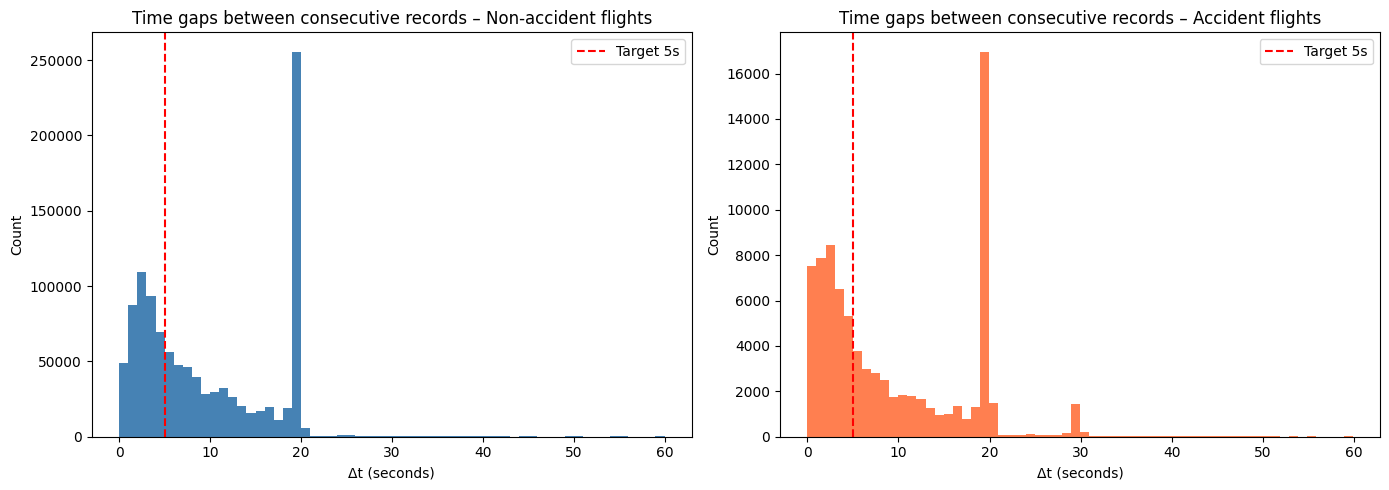

In [194]:
import matplotlib.pyplot as plt

# Convert to seconds
delta_normal_sec = delta_normal.dt.total_seconds().drop_nulls().to_numpy()
delta_acc_sec = delta_acc.dt.total_seconds().dropna().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal (clip at 60s for readability)
axes[0].hist(delta_normal_sec[delta_normal_sec <= 60], bins=60, color="steelblue")
axes[0].set_title("Time gaps between consecutive records – Non-accident flights")
axes[0].set_xlabel("Δt (seconds)")
axes[0].set_ylabel("Count")
axes[0].axvline(5, color="red", linestyle="--", label="Target 5s")
axes[0].legend()

# Accidents
axes[1].hist(delta_acc_sec[delta_acc_sec <= 60], bins=60, color="coral")
axes[1].set_title("Time gaps between consecutive records – Accident flights")
axes[1].set_xlabel("Δt (seconds)")
axes[1].set_ylabel("Count")
axes[1].axvline(5, color="red", linestyle="--", label="Target 5s")
axes[1].legend()

plt.tight_layout()
plt.show()

Both datasets show a bimodal distribution of time deltas. There is a first peak around 2–4 seconds, likely corresponding to low-altitude phases (approach, landing) where many ground-based ADS-B receivers are in range and update frequency is high. A second dominant peak sits around 20 seconds, typical of cruise phase where fewer receivers are available.

In [59]:
import datetime as dt
for t in [5, 10, 15, 20, 30, 60, 120]:
    threshold = dt.timedelta(seconds=t)
    n_normal = (delta_normal > threshold).sum()
    n_acc = (delta_acc > threshold).sum()
    print(f"> {t}s: Normal {n_normal:,} ({n_normal/len(delta_normal)*100:.2f}%), Accident {n_acc:,} ({n_acc/len(delta_acc)*100:.2f}%)")

> 5s: Normal 684,551 (62.70%), Accident 47,849 (56.75%)
> 10s: Normal 467,578 (42.83%), Accident 33,903 (40.21%)
> 15s: Normal 344,362 (31.54%), Accident 26,332 (31.23%)
> 20s: Normal 20,960 (1.92%), Accident 3,505 (4.16%)
> 30s: Normal 13,862 (1.27%), Accident 1,000 (1.19%)
> 60s: Normal 7,277 (0.67%), Accident 467 (0.55%)
> 120s: Normal 2,904 (0.27%), Accident 202 (0.24%)


Over 62% of normal flight gaps and 56% of accident gaps exceed 5 seconds, and over 42% and 33% respectively exceed 10 seconds. This confirms that the raw data is irregular, neither 5s nor 10s reflects a natural dominant sampling rate. However, gaps beyond 20 seconds drop sharply to just ~ 2% for normal flights and ~4% for accidents, meaning the vast majority of measurements are clustered below the 20-second mark.

We aim for 5 seconds as our resampling target for three reasons:

- First, it aligns with the first natural peak observed in the time delta distribution (2–4s), preserving high-frequency ADS-B coverage during critical low-altitude phases without over-interpolating cruise phase gaps. 

- Second, critical flight phases like approach and landing, where a significant proportion of accidents occur, tend to have denser ADS-B coverage at 2–4s intervals, and a 5s grid preserves this resolution better than 10s or 20s would. Third, at 5s intervals a median flight of ~57 minutes yields ~684 time steps per flight, which remains a practical sequence length for both tsfresh feature extraction and the autoencoder.

We considered a 3-second target to match the high-frequency peak even more closely, but rejected it as it would result in excessive interpolation during cruise phase (we assume), where the original sampling rate is ~20 seconds (our second peak) effectively fabricating 6–7 synthetic points per real measurement.

Let's investigate two flights where the plane dropped the most, in other words, potential crash candidates.

In [60]:
candidates = (
    df_acc.groupby("flight_id")
    .agg(
        n_points=("timestamp", "size"),
        max_descent=("vertical_rate", "min"),
        max_climb=("vertical_rate", "max")
    )
    .sort_values("max_descent")
    .head(10)
)
print(candidates)

           n_points  max_descent  max_climb
flight_id                                  
8940cc          584      -8000.0      128.0
a02dda         1621      -8000.0     4608.0
a6456d          134      -8000.0     8000.0
ac2bd5          612      -8000.0     8000.0
e49b02          336      -8000.0     5440.0
3985a9          674      -6336.0     3456.0
8467d8          456      -6336.0     5632.0
a4d838          297      -5888.0       64.0
a1f94c          483      -5824.0     4352.0
4b17fb          455      -5760.0     4416.0


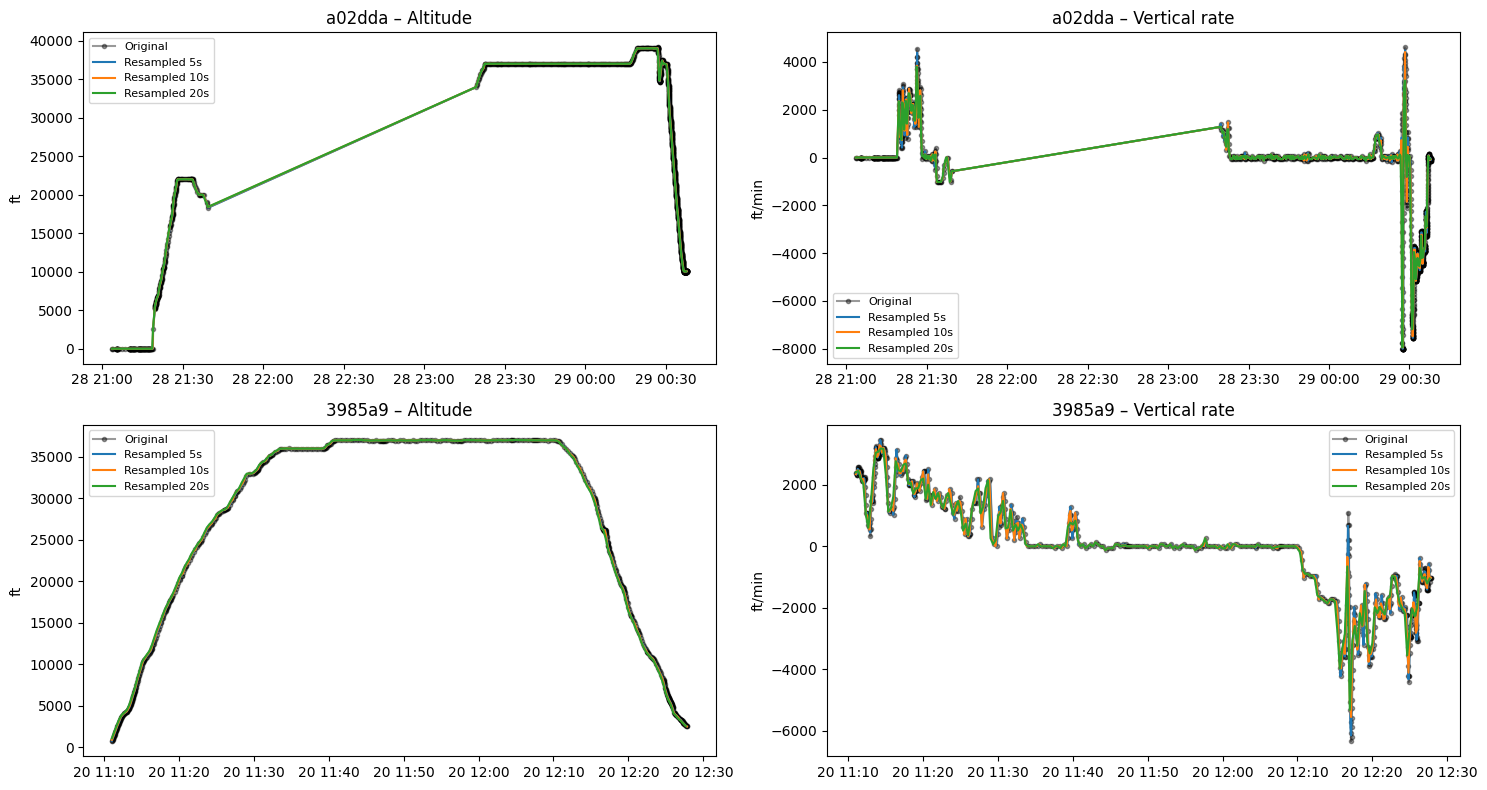

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

example_flights = ["a02dda", "3985a9"]
resample_rates = ["5s", "10s", "20s"]

fig, axes = plt.subplots(len(example_flights), 2, figsize=(15, 8))

for row, fid in enumerate(example_flights):
    flight = df_acc[df_acc["flight_id"] == fid].sort_values("timestamp").set_index("timestamp")
    
    # Altitude
    ax_alt = axes[row, 0]
    ax_alt.plot(flight.index, flight["altitude"], "o-", color="black", alpha=0.4, markersize=3, label="Original")
    for rate in resample_rates:
        resampled = flight["altitude"].resample(rate).mean().interpolate("linear")
        ax_alt.plot(resampled.index, resampled.values, label=f"Resampled {rate}", linewidth=1.5)
    ax_alt.set_title(f"{fid} – Altitude")
    ax_alt.set_ylabel("ft")
    ax_alt.legend(fontsize=8)
    
    # Vertical rate
    ax_vr = axes[row, 1]
    ax_vr.plot(flight.index, flight["vertical_rate"], "o-", color="black", alpha=0.4, markersize=3, label="Original")
    for rate in resample_rates:
        resampled = flight["vertical_rate"].resample(rate).mean().interpolate("linear")
        ax_vr.plot(resampled.index, resampled.values, label=f"Resampled {rate}", linewidth=1.5)
    ax_vr.set_title(f"{fid} – Vertical rate")
    ax_vr.set_ylabel("ft/min")
    ax_vr.legend(fontsize=8)

plt.tight_layout()
plt.show()

We see that 5 and 10 second resmapling rate are the winner here as it contains more information. For now we aim for the 5s sampling rate.

Resampling strategy per column (target: 5s intervals):

Linear interpolation:
- lat, lon, altitude, altitude_geom, ground_speed, vertical_rate
  → These are continuous physical signals that change smoothly over time, 
    making linear interpolation a faithful approximation between samples.

Circular interpolation (wrap-around aware):
- track_degrees (0–360°)
  → Heading wraps from 359° to 0°, so a naive linear average would jump 
    to 180° instead of crossing zero. Circular interpolation handles this correctly.

Forward fill:
- flags, source
  → These are discrete categorical values that don't have meaningful 
    intermediate states, so we carry the last known value forward.

Constant (no resampling needed):
- icao, flight_id, type
  → These are flight-level metadata that stay constant across all timestamps.

In [63]:
df_acc = df_acc.drop(columns=["h3_5"], errors="ignore")
df_normal_final = df_normal_final.drop("h3_5")  

In [64]:
df_acc_resampled = resample_all(df_acc, freq="5s")

Resampling:   0%|          | 0/161 [00:00<?, ?it/s]

Resampling: 100%|██████████| 161/161 [00:02<00:00, 78.93it/s]


In [65]:
print(f"Original rows: {len(df_acc)}")
print(f"Resampled rows: {len(df_acc_resampled)}")
print(f"Flights: {df_acc_resampled['flight_id'].nunique()}")

Original rows: 84318
Resampled rows: 219345
Flights: 161


In [67]:
df_normal_resampled = resample_all(df_normal_final.to_pandas(), freq="5s")

Resampling: 100%|██████████| 1999/1999 [00:01<00:00, 1088.49it/s]


In [68]:
print(f"Original rows: {len(df_normal_final)}")
print(f"Resampled rows: {len(df_normal_resampled)}")
print(f"Flights: {df_normal_resampled['flight_id'].nunique()}")

Original rows: 1091762
Resampled rows: 2804524
Flights: 1999


Resampled both datasets to a fixed 5s grid (linear interpolation, circular for track_degrees, ffill for discrete cols)

In [69]:
check_nan(df_normal_resampled)

⚠️ NaN summary:
               NaN_count NaN_percent
timestamp              0       0.0 %
lat                    0       0.0 %
lon                    0       0.0 %
altitude               0       0.0 %
altitude_geom          0       0.0 %
ground_speed           0       0.0 %
vertical_rate          0       0.0 %
flags                  0       0.0 %
source                 0       0.0 %
track_degrees          0       0.0 %
icao                   0       0.0 %
flight_id              0       0.0 %
type                   0       0.0 %


In [70]:
check_nan(df_acc_resampled)

⚠️ NaN summary:
               NaN_count NaN_percent
timestamp              0       0.0 %
lat                    0       0.0 %
lon                    0       0.0 %
altitude               0       0.0 %
altitude_geom          0       0.0 %
ground_speed           0       0.0 %
vertical_rate          0       0.0 %
flags                  0       0.0 %
source                 0       0.0 %
track_degrees          0       0.0 %
icao                   0       0.0 %
flight_id              0       0.0 %
type                   0       0.0 %
t0                     0       0.0 %


In [71]:
from datetime import timedelta

In [ ]:
# Accidents
acc_lengths = (
    df_acc_resampled
    .groupby("flight_id")
    .agg(n_points=("timestamp", "size"), duration=("timestamp", lambda x: x.max() - x.min()))
)
print("\n=== Accidents ===")
print(acc_lengths.describe())


=== Accidents ===
          n_points                duration
count   161.000000                     161
mean   1362.391304  0 days 01:53:26.956521
std    1077.848506  0 days 01:29:49.242530
min      31.000000         0 days 00:02:30
25%     536.000000         0 days 00:44:35
50%    1036.000000         0 days 01:26:15
75%    1947.000000         0 days 02:42:10
max    4078.000000         0 days 05:39:45


In [ ]:
acc_lengths = (
    df_normal_resampled
    .groupby("flight_id")
    .agg(n_points=("timestamp", "size"), duration=("timestamp", lambda x: x.max() - x.min()))
)
print("\n=== Normal Flights ===")
print(acc_lengths.describe())


=== Normal Flights ===
          n_points                duration
count  1999.000000                    1999
mean   1402.963482  0 days 01:56:49.817408
std    1081.839839  0 days 01:30:09.199195
min     241.000000         0 days 00:20:00
25%     643.500000  0 days 00:53:32.500000
50%    1116.000000         0 days 01:32:55
75%    1833.500000  0 days 02:32:42.500000
max    9985.000000         0 days 13:52:00


#### Export the preprocessed-dataset

In [74]:
df_acc_resampled.dtypes

timestamp        datetime64[us, UTC]
lat                          float64
lon                          float64
altitude                     float64
altitude_geom                float64
ground_speed                 float64
vertical_rate                float64
flags                        float64
source                           str
track_degrees                float64
icao                             str
flight_id                        str
type                             str
t0                               str
dtype: object

In [75]:
print(f"Flights: {df_acc_resampled['flight_id'].nunique()}")

Flights: 161


In [76]:
print(f"Flights: {df_normal_resampled['flight_id'].nunique()}")

Flights: 1999


In [77]:
export_df(df_acc_resampled, PRE_PROCESSED_DIR, "accident_traces_5s.csv")
export_df(df_acc_resampled, PRE_PROCESSED_DIR, "accident_traces_5s.parquet")

In [ ]:

export_df(df_normal_resampled, PRE_PROCESSED_DIR, "normal_traces_5s.parquet")

In [78]:
# df_pl = pl.from_pandas(df_normal_resampled)
# df_pl.write_parquet(PRE_PROCESSED_DIR / "normal_traces.parquet")